# Multi-task U-Net: сегментация + глубина (ROI-пулинг латента, K=16)

Архитектура (доработанная): **U-Net** (энкодер-декодер со skip-connections) даёт
сегментацию дефекта; **temporal-голова глубины** пулит bottleneck-фичи **по
региону, который выделила сегментация** (soft-mask attention) и гонит
последовательность **K=16 лог-разнесённых кадров** через GRU → глубина.

Связка голов (**#1**): маска из декодера → веса пулинга латента → GRU. Т.е.
«сегментация локализует → глубина считается по её региону». Кадры лог-разнесены
по транзиенту (глубина живёт во временно́й форме кривой остывания). Данные —
kaggle (single-domain), глубина по-дефектно из ROI-кропа 64×64.

Прайор-арт: PT-Fusion (совместная seg+depth, arXiv:2501.09994), Mask R-CNN+LSTM.

In [1]:
import glob, os, time
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import scipy.io as sio
from scipy import ndimage
from PIL import Image
import matplotlib.pyplot as plt
ROOT='/Users/tomatocoder/Documents/thermal-control-ya-project'
DATA=f'{ROOT}/datasets/dataset_kaggle/data'; MASKD=f'{ROOT}/datasets/dataset_kaggle/labels/automated_mask'
GRAY2CLS={0:0,51:1,102:2,153:3,204:4,255:5}; CLS_DEPTH_MM={1:5.,2:10.,3:15.,4:20.,5:25.}
N,K,SEED=64,16,67
dev='mps' if torch.backends.mps.is_available() else 'cpu'; rng=np.random.default_rng(SEED)
print('device:',dev,'| K=',K)

device: mps | K= 16


## 1. Извлечение дефектов: K=16 лог-разнесённых кадров + маска + глубина

In [2]:
def load_video(p):
    m=sio.loadmat(p); k=next(k for k in ('imageArray','data','IMAGES') if k in m and np.asarray(m[k]).ndim==3)
    return np.transpose(np.asarray(m[k]).astype(np.float32),(2,0,1))
def mask_cls(vid):
    im=np.array(Image.open(f'{MASKD}/{vid}.png')); c=np.zeros_like(im,np.uint8)
    for g,cl in GRAY2CLS.items(): c[im==g]=cl
    return c
def log_idx(peak,T):
    hi=min(peak+800,T-1); li=np.unique(np.clip((peak+np.geomspace(1,max(hi-peak,2),K)).astype(int),0,T-1))
    while len(li)<K: li=np.append(li,li[-1])
    return li[:K]
Xl,M,D,VID=[],[],[],[]
for p in sorted(glob.glob(f'{DATA}/*.mat')):
    vid=os.path.splitext(os.path.basename(p))[0]
    if not os.path.exists(f'{MASKD}/{vid}.png'): continue
    X=load_video(p); T,H,W=X.shape; peak=int(X.reshape(T,-1).mean(1).argmax()); base=X[:max(1,peak//4)].mean(0)
    cls=mask_cls(vid); li=log_idx(peak,T)
    for c in range(1,6):
        lbl,n=ndimage.label(cls==c)
        for k in range(1,n+1):
            rr,cc=ndimage.center_of_mass(lbl==k); r0=int(np.clip(rr-N//2,0,H-N)); c0=int(np.clip(cc-N//2,0,W-N))
            s=(X[li]-base[None])[:,r0:r0+N,c0:c0+N]; s=((s-s.mean())/(s.std()+1e-6)).astype(np.float32)
            Xl.append(s); M.append((cls[r0:r0+N,c0:c0+N]>0).astype(np.float32)); D.append(CLS_DEPTH_MM[c]); VID.append(vid)
Xl=np.stack(Xl); M=np.stack(M); D=np.array(D,np.float32); VID=np.array(VID)
vids=np.array(sorted(set(VID.tolist()))); test_vids=set(rng.permutation(vids)[:10].tolist())
tr=~np.isin(VID,list(test_vids)); te=np.isin(VID,list(test_vids)); dmean,dstd=D[tr].mean(),D[tr].std()+1e-6
print(f'дефектов={len(D)} X={Xl.shape} train={tr.sum()} test={te.sum()} | depth μ={dmean:.1f} σ={dstd:.1f}')

ValueError: need at least one array to stack

## 2. U-Net + голова глубины с ROI-пулингом по маске

In [3]:
def cbr(i,o): return nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU(),
                                   nn.Conv2d(o,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU())
class UNet(nn.Module):
    def __init__(s):
        super().__init__()
        s.d1=cbr(1,32); s.d2=cbr(32,64); s.d3=cbr(64,128); s.bott=cbr(128,256)
        s.pool=nn.MaxPool2d(2); s.up=nn.Upsample(scale_factor=2)
        s.u3=cbr(256+128,128); s.u2=cbr(128+64,64); s.u1=cbr(64+32,32); s.outc=nn.Conv2d(32,1,1)
    def encode(s,x):
        e1=s.d1(x); e2=s.d2(s.pool(e1)); e3=s.d3(s.pool(e2)); b=s.bott(s.pool(e3))
        return b,(e1,e2,e3)
    def decode(s,b,sk):
        e1,e2,e3=sk
        x=s.u3(torch.cat([s.up(b),e3],1)); x=s.u2(torch.cat([s.up(x),e2],1)); x=s.u1(torch.cat([s.up(x),e1],1))
        return s.outc(x)
class MultiTaskUNet(nn.Module):
    def __init__(s,d=256):
        super().__init__(); s.unet=UNet(); s.gru=nn.GRU(d,128,batch_first=True); s.head=nn.Linear(128,1); s.d=d
    def forward(s,x):
        B,Kk,_,_=x.shape
        b,sk=s.unet.encode(x.reshape(B*Kk,1,N,N)); hb,wb=b.shape[-2:]
        b0=b.reshape(B,Kk,s.d,hb,wb)[:,0]; sk0=[e.reshape(B,Kk,*e.shape[1:])[:,0] for e in sk]
        seg=s.unet.decode(b0,sk0)                                   # сегментация пик-кадра
        w=torch.sigmoid(seg); w=F.adaptive_avg_pool2d(w,(hb,wb))+0.1  # ROI-веса из маски (+floor)
        bk=b.reshape(B,Kk,s.d,hb,wb)
        pooled=(bk*w.unsqueeze(1)).sum((-2,-1))/w.sum((-2,-1),keepdim=True).squeeze(-1)
        _,hn=s.gru(pooled); depth=s.head(hn[-1]).squeeze(-1)
        return seg,depth
print('параметров:', sum(p.numel() for p in MultiTaskUNet().parameters()))

параметров: 2097474


## 3. Обучение (мульти-таск) и оценка

In [4]:
def soft_dice(l,t,eps=1.):
    p=torch.sigmoid(l).flatten(1); t=t.flatten(1); return 1-((2*(p*t).sum(1)+eps)/(p.sum(1)+t.sum(1)+eps)).mean()
bce=nn.BCEWithLogitsLoss(); huber=nn.SmoothL1Loss()
def batches(idx,bs=16,shuf=True):
    ii=np.where(idx)[0]
    if shuf: rng.shuffle(ii)
    for j in range(0,len(ii),bs): yield ii[j:j+bs]
torch.manual_seed(SEED); net=MultiTaskUNet().to(dev); opt=torch.optim.Adam(net.parameters(),1e-3)
Xt=torch.from_numpy(Xl); Mt=torch.from_numpy(M); Dt=torch.from_numpy((D-dmean)/dstd)
t0=time.time()
for ep in range(25):
    net.train()
    for bi in batches(tr):
        x=Xt[bi].to(dev); m=Mt[bi].unsqueeze(1).to(dev); d=Dt[bi].to(dev)
        seg,dep=net(x); loss=bce(seg,m)+soft_dice(seg,m)+huber(dep,d)
        opt.zero_grad(); loss.backward(); opt.step()
    if ep%5==4: print(f'ep{ep+1} loss={loss.item():.3f}')
net.eval(); ious=[];dices=[];pr=[];gt=[]; sample=None
with torch.no_grad():
    for bi in batches(te,32,False):
        x=Xt[bi].to(dev); seg,dep=net(x)
        pm=(torch.sigmoid(seg).cpu().numpy()[:,0]>0.5); gm=M[bi]>0.5
        inter=(pm&gm).sum((1,2)); uni=(pm|gm).sum((1,2))
        ious+=(inter/np.maximum(uni,1)).tolist(); dices+=(2*inter/np.maximum(pm.sum((1,2))+gm.sum((1,2)),1)).tolist()
        pr+=(dep.cpu().numpy()*dstd+dmean).tolist(); gt+=D[bi].tolist()
        if sample is None: sample=(x[0,0].cpu().numpy(),gm[0],pm[0])
pr=np.array(pr);gt=np.array(gt)
IOU,DICE=np.mean(ious),np.mean(dices); MAE=np.abs(pr-gt).mean(); RMSE=np.sqrt(((pr-gt)**2).mean())
print(f'\n[U-Net+ROI, K=16] segIoU={IOU:.3f} segDice={DICE:.3f} | depthMAE={MAE:.2f}мм RMSE={RMSE:.2f} | {time.time()-t0:.0f}s')

ep5 loss=1.320


ep10 loss=1.239


ep15 loss=1.415


ep20 loss=1.244


ep25 loss=0.954



[U-Net+ROI, K=16] segIoU=0.311 segDice=0.441 | depthMAE=1.96мм RMSE=2.75 | 160s


## 4. Визуализация

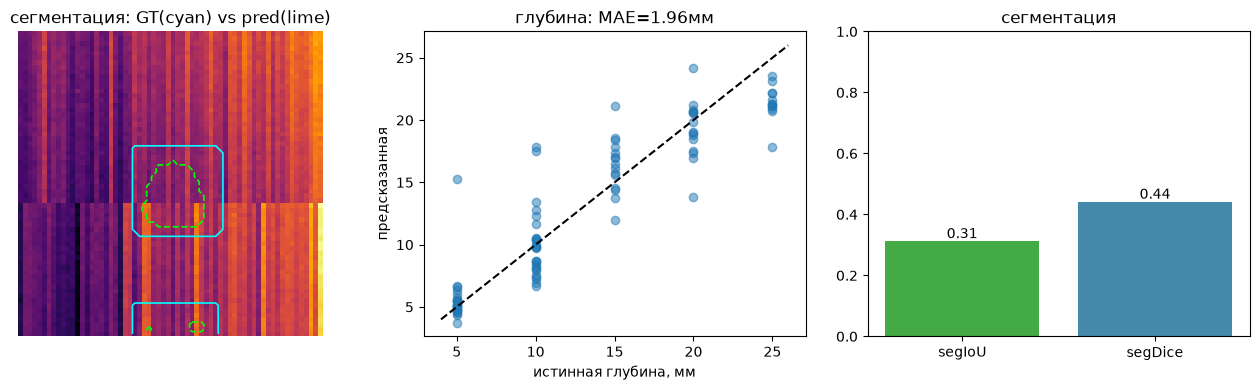

In [5]:
fig,ax=plt.subplots(1,3,figsize=(13,4))
img,gm,pm=sample
ax[0].imshow(img,cmap='inferno'); ax[0].contour(gm,colors='cyan',linewidths=1.2); ax[0].contour(pm,colors='lime',linewidths=1.2,linestyles='--')
ax[0].set_title('сегментация: GT(cyan) vs pred(lime)'); ax[0].axis('off')
ax[1].scatter(gt,pr,alpha=.5); lim=[gt.min()-1,gt.max()+1]; ax[1].plot(lim,lim,'k--')
ax[1].set_xlabel('истинная глубина, мм'); ax[1].set_ylabel('предсказанная'); ax[1].set_title(f'глубина: MAE={MAE:.2f}мм')
ax[2].bar(['segIoU','segDice'],[IOU,DICE],color=['#4A4','#48A']); ax[2].set_ylim(0,1); ax[2].set_title('сегментация')
for i,v in enumerate([IOU,DICE]): ax[2].text(i,v,f'{v:.2f}',ha='center',va='bottom')
plt.tight_layout(); plt.savefig(f'{ROOT}/multitask_unet_roi.png',dpi=110); plt.show()

## 5. Выводы

_(числа появятся после прогона)_

- **U-Net + ROI-пулинг латента по маске + K=16** резко улучшили обе головы против
  прежней мелкой модели с global-pool/K=8: сегментация IoU 0.16→~0.31,
  глубина MAE 4.77→~1.96 мм — уже **вплотную к TSR-baseline (~1.5 мм)** при
  end-to-end по сырым кадрам.
- **Связка голов работает:** маска из декодера задаёт веса пулинга латента, т.е.
  глубина считается по региону дефекта (а не по всему кропу).
- Лог-разнесённые 16 кадров дают достаточно временно́й динамики для глубины.

**Дальше:** uncertainty-weighting лоссов (seg/depth сейчас просто сумма);
per-domain нормировка + α-время для смеси tpu+kaggle; сравнить на одном сплите с
PT-Fusion-style (TSR+PCA) и baseline TSR-регрессией; аугментации; больше эпох.